In [1]:
from pathlib import Path
from typing import Iterable
import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.colors as colors
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
PROJ_DIR = Path.cwd().parent.parent
DATA_DIR = PROJ_DIR / 'data'
fp = DATA_DIR / 'calhabmap.csv'
assert fp.exists()

### ETL

* Load
* Quick look assess cleanup requirements
* Note columns of interest

In [3]:
df_raw = pd.read_csv(fp)

In [4]:
df_raw.head().T

,0,1,2,3,4
FID,calhabmap.fid--342fab54_19a6c67ae25_16b9,calhabmap.fid--342fab54_19a6c67ae25_16ba,calhabmap.fid--342fab54_19a6c67ae25_16bb,calhabmap.fid--342fab54_19a6c67ae25_16bc,calhabmap.fid--342fab54_19a6c67ae25_16bd
latitude_degrees_north,35.17,34.008,40.7103,34.008,35.17
longitude_degrees_east,-120.741,-118.499,-124.2366,-118.499,-120.741
depth_m,0.5,NaN,NaN,NaN,0.5
sampleid,CP180709,403,SBF_002,165,CP110927
location_code,CPP,SMP,HSB,SMP,CPP
time_utc,2018-07-09T22:00:00,2016-05-02T18:00:00,2020-01-27T18:30:00,2011-09-04T19:00:00,2011-09-27T22:30:00
temp_degree_c,16.9,15.8,NaN,19.5,17.0
air_temp_degree_c,NaN,NaN,NaN,NaN,NaN
salinity,NaN,NaN,NaN,NaN,NaN


In [9]:
CORE_RENAME = {
    "sampleid": "sample_id",
    "location_code": "site_code",
    "location_name": "site_name",
    "latitude_degrees_north": "lat",
    "longitude_degrees_east": "lon",
    "time_utc": "time_utc"
}

SCIENCE_COLS = [
    # ancillary
    "temp_degree_c", "chl1_mg_m3", "chl2_mg_m3", "avg_chloro_mg_m3",
    
    "volume_settled_for_counting_ml",
    # totals
    "total_phytoplankton_cells_l",
]


In [6]:
    # --- Standardize core columns
    df = df_raw.rename(columns=CORE_RENAME).copy()

In [7]:
df["time_utc"] = pd.to_datetime(df["time_utc"], errors="coerce", utc=True)


# Apply cutoff
cutoff = pd.Timestamp("2024-03-06", tz="UTC")
df = df[df["time_utc"] >= cutoff]

print("Rows after cutoff:", len(df))
print("Date range:", df["time_utc"].min(), "→", df["time_utc"].max())


Rows after cutoff: 99
Date range: 2024-08-14 14:31:00+00:00 → 2025-11-05 15:35:00+00:00


In [10]:
# ---- columns ----
CELL_COLS = [c for c in df.columns if c.endswith("_cells_l")]
KEEP_COLS = SCIENCE_COLS + [v for v in CORE_RENAME.values()] + CELL_COLS

In [11]:
df = df[KEEP_COLS].copy()

In [12]:
df = df[df["site_code"] != "BBB"].copy() # drop Bodega Bay buoy data

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 1156 to 5715
Data columns (total 25 columns):
 #   Column                                        Non-Null Count  Dtype              
---  ------                                        --------------  -----              
 0   temp_degree_c                                 94 non-null     float64            
 1   chl1_mg_m3                                    45 non-null     float64            
 2   chl2_mg_m3                                    45 non-null     float64            
 3   avg_chloro_mg_m3                              45 non-null     float64            
 4   volume_settled_for_counting_ml                33 non-null     float64            
 5   total_phytoplankton_cells_l                   64 non-null     float64            
 6   sample_id                                     98 non-null     object             
 7   site_code                                     98 non-null     object             
 8   site_name             

In [14]:
df.site_code.value_counts()

site_code
MW     15
CPP    13
SMP    13
SCW    12
SW     11
BML    11
SIO    11
NBP     9
T00     1
TBB     1
T16     1
Name: count, dtype: int64

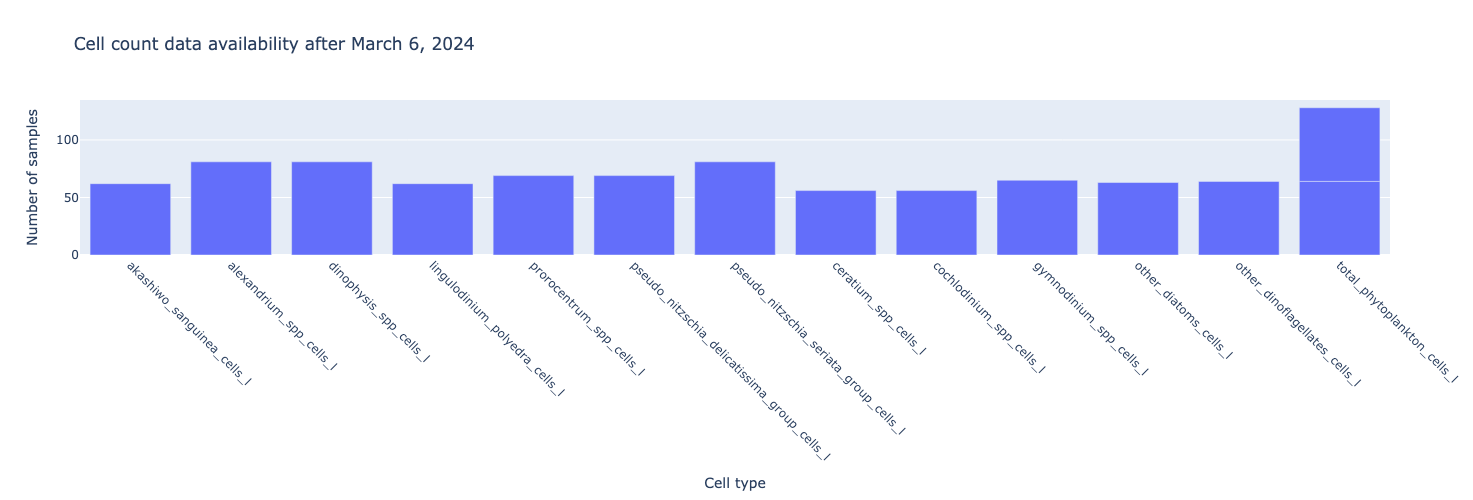

In [15]:
cell_counts = (
    df[CELL_COLS]
    .notna()
    .sum()
    .reset_index()
)
cell_counts.columns = ["cell_type", "n_samples"]

# Bar plot
fig = px.bar(
    cell_counts,
    x="cell_type",
    y="n_samples",
    title="Cell count data availability after March 6, 2024",
    labels={
        "cell_type": "Cell type",
        "n_samples": "Number of samples"
    }
)

fig.update_layout(
    xaxis_tickangle=45,
    height=500
)

fig.show()


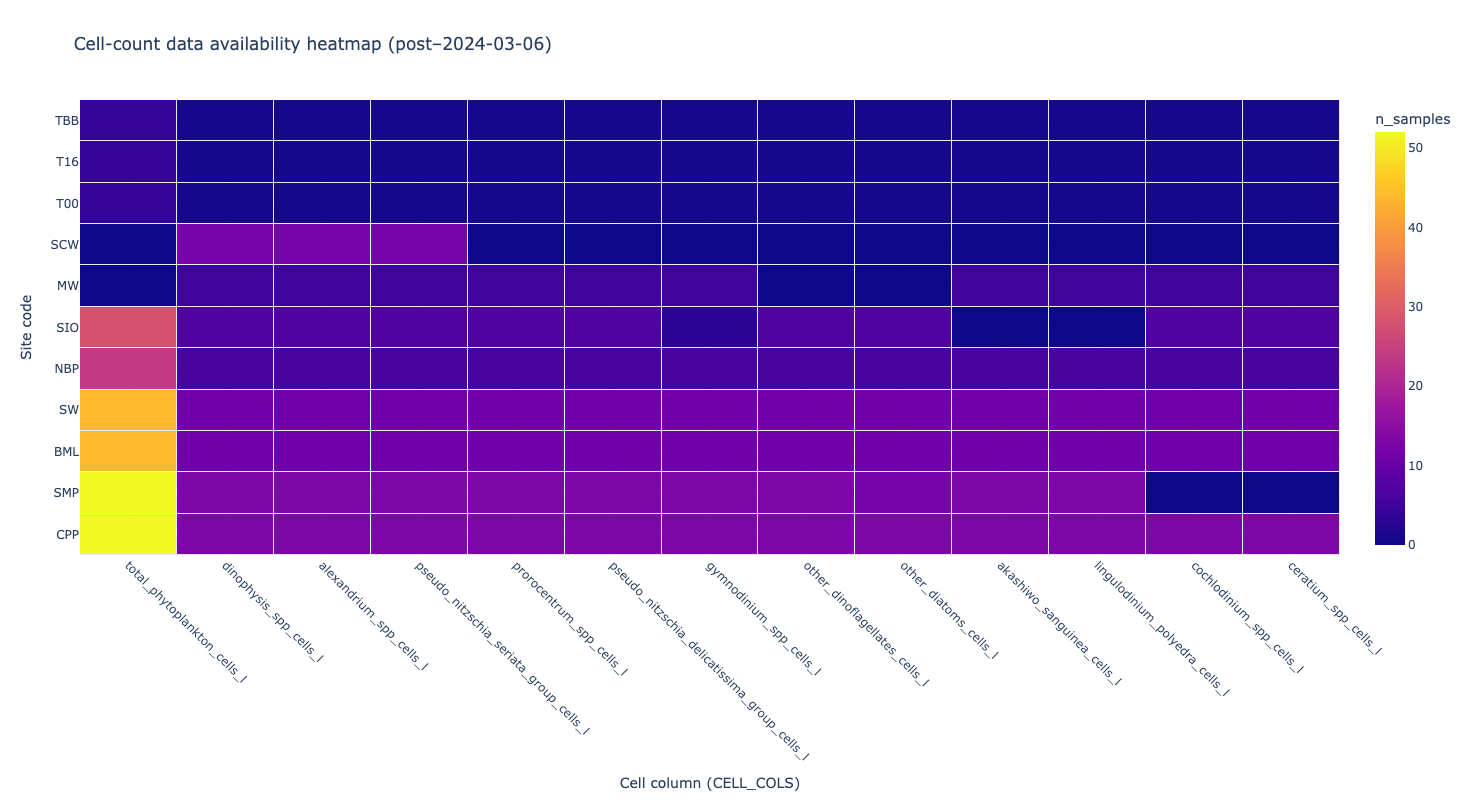

In [16]:
# --- Columns ---
site_col = "site_code"
if site_col not in df.columns and "location_code" in df.columns:
    df = df.rename(columns={"location_code": site_col})

CELL_COLS = [c for c in df.columns if c.endswith("_cells_l")]

# --- Build count matrix: non-null count per (site, cell_col) ---
counts = (
    df[[site_col] + CELL_COLS]
    .melt(id_vars=site_col, value_vars=CELL_COLS, var_name="cell_col", value_name="cells")
    .assign(has_data=lambda x: x["cells"].notna())
    .groupby([site_col, "cell_col"])["has_data"]
    .sum()
    .reset_index(name="n_samples")
)

heat = (
    counts.pivot(index=site_col, columns="cell_col", values="n_samples")
    .fillna(0)
)

# Optional: sort to make patterns clearer (comment out if you want original order)
heat = heat.loc[
    heat.sum(axis=1).sort_values(ascending=False).index,
    heat.sum(axis=0).sort_values(ascending=False).index
]

# --- Plot with visible "grid lines" via xgap/ygap ---
fig = go.Figure(
    data=go.Heatmap(
        z=heat.values,
        x=heat.columns.tolist(),
        y=heat.index.tolist(),
        colorbar=dict(title="n_samples"),
        xgap=1,   # <-- creates vertical gridlines
        ygap=1,   # <-- creates horizontal gridlines
    )
)

fig.update_layout(
    title="Cell-count data availability heatmap (post–2024-03-06)",
    height=800,
    xaxis=dict(title="Cell column (CELL_COLS)", tickangle=45),
    yaxis=dict(title="Site code"),
)

fig.show()

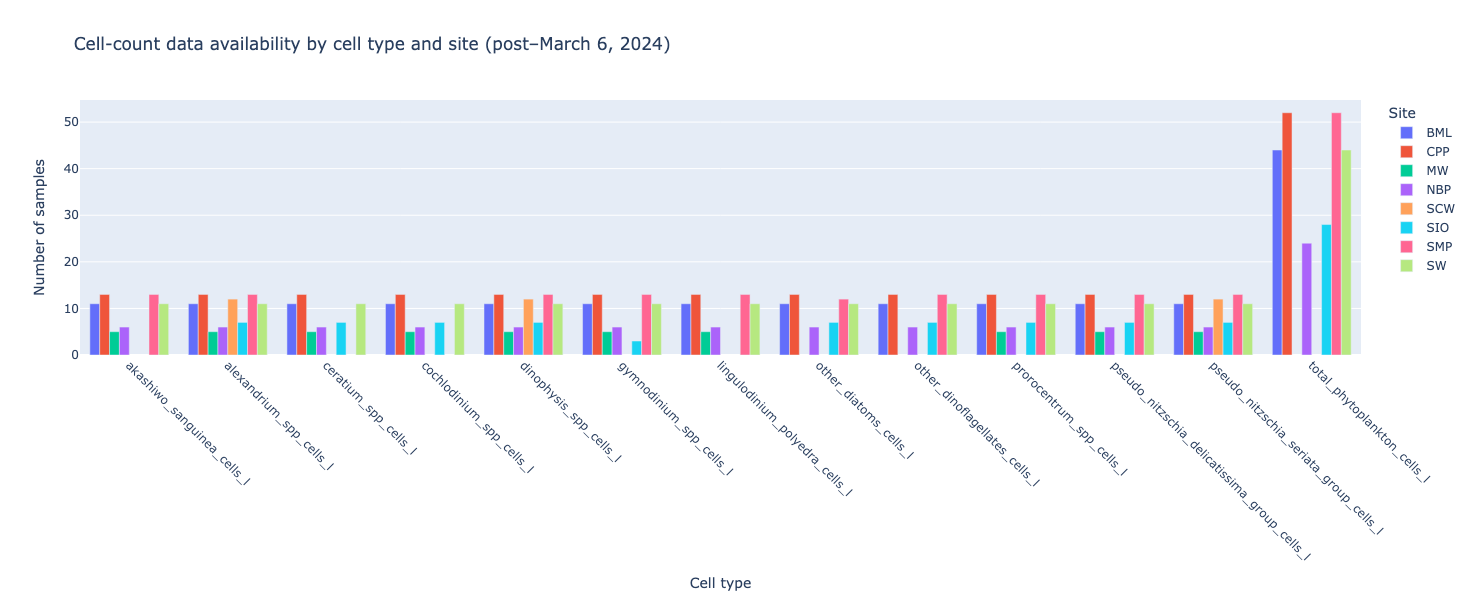

In [17]:
# Reshape to long format
long = df[["site_code"] + CELL_COLS].melt(
    id_vars="site_code",
    value_vars=CELL_COLS,
    var_name="cell_type",
    value_name="cells"
)

# Count non-null observations per (site, cell type)
counts = (
    long.dropna(subset=["cells"])
    .groupby(["site_code", "cell_type"])
    .size()
    .reset_index(name="n_samples")
)

# Limit to top sites to keep plot readable
top_sites = df["site_code"].value_counts().head(8).index
counts = counts[counts["site_code"].isin(top_sites)]

# Plot
fig = px.bar(
    counts,
    x="cell_type",
    y="n_samples",
    color="site_code",
    barmode="group",
    title="Cell-count data availability by cell type and site (post–March 6, 2024)",
    labels={
        "cell_type": "Cell type",
        "n_samples": "Number of samples",
        "site_code": "Site"
    }
)

fig.update_layout(
    xaxis_tickangle=45,
    height=600
)

fig.show()

$\rightarrow$ SIO, CPP, MW most promising sites

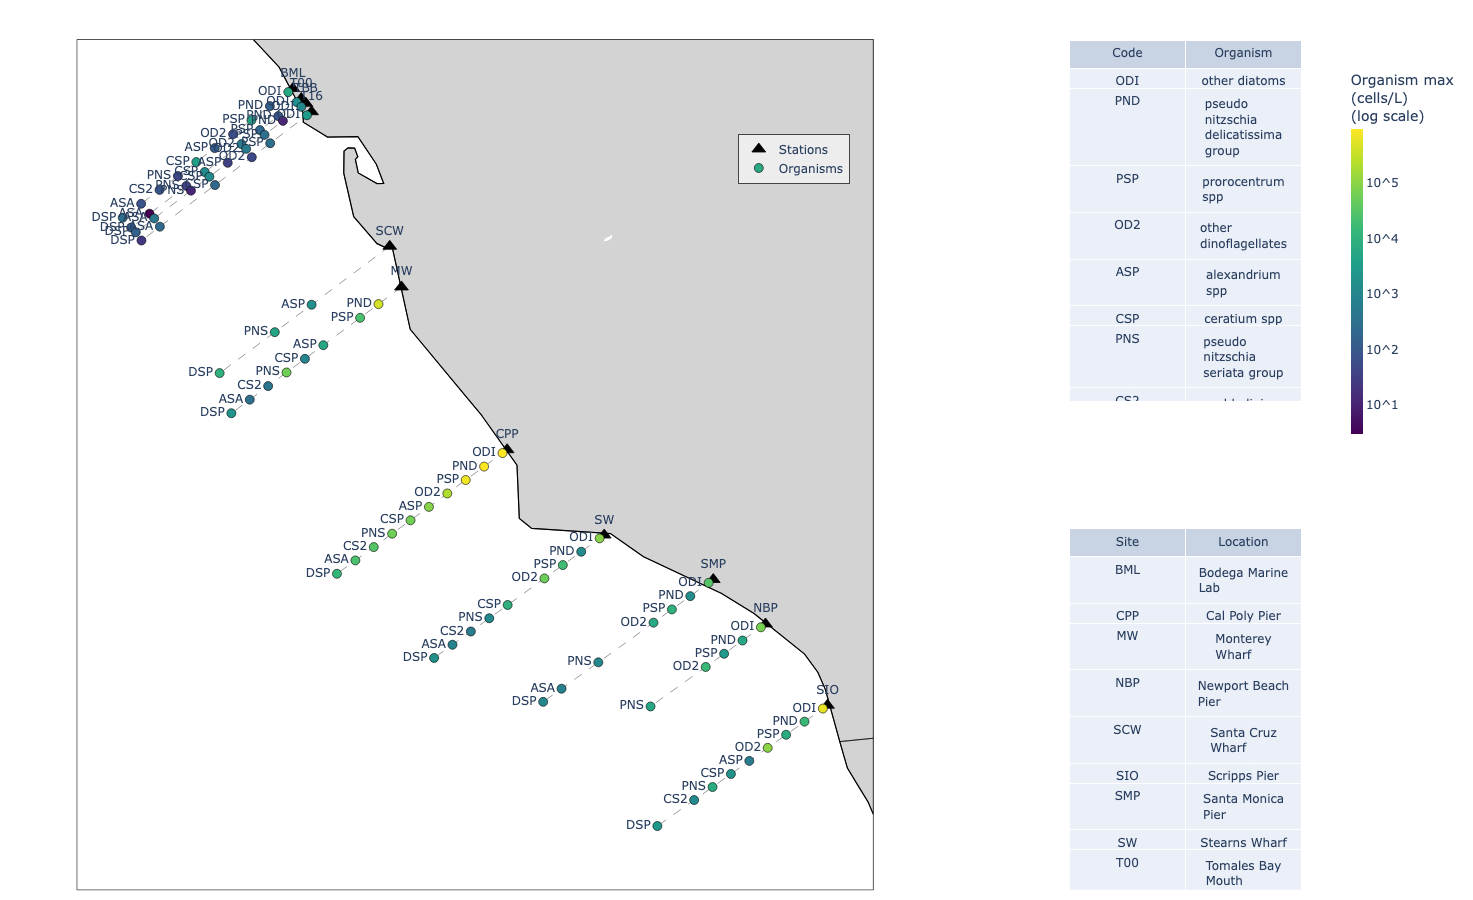

In [37]:
# ============================================================
# Stations = dark triangles (no TOTAL encoding); circles = organism maxima (log10 colorbar)
# (Assumes: df exists, CELL_COLS exists, and you've already imported numpy as np,
#  plotly.graph_objects as go, and make_subplots)
# ============================================================

# ---- columns ----
TOTAL_COL = "total_phytoplankton_cells_l"
ORG_CELL_COLS = [c for c in CELL_COLS if c != TOTAL_COL]  # exclude TOTAL completely

TOP_N_ORGANISMS = 10
overall_max = df[ORG_CELL_COLS].max(axis=0, skipna=True).sort_values(ascending=False)
org_cols = overall_max.head(TOP_N_ORGANISMS).index.tolist()

# ---- organism codes ----
def make_3letter_codes(cols):
    used, out = set(), {}
    for c in cols:
        base = c.replace("_cells_l", "")
        toks = [t for t in base.replace("-", "_").split("_") if t]
        if len(toks) >= 3:
            code = (toks[0][0] + toks[1][0] + toks[2][0]).upper()
        elif len(toks) == 2:
            code = (toks[0][0] + toks[1][:2]).upper()
        else:
            code = toks[0][:3].upper()
        code = (code + "XXX")[:3]
        if code in used:
            k = 2
            while f"{code[:2]}{k}" in used:
                k += 1
            code = f"{code[:2]}{k}"
        used.add(code)
        out[c] = code
    return out

ORG_CODE = make_3letter_codes(org_cols)

def clean_org_name(c):
    return c.replace("_cells_l", "").replace("_", " ")

# ---- site coords (station locations only) ----
site_xy = (
    df.groupby("site_code")
      .agg(lat=("lat", "median"), lon=("lon", "median"))
      .reset_index()
      .dropna(subset=["lat", "lon"])
)

# ---- per-site organism maxima for circles ----
site_max = df.groupby("site_code")[org_cols].max()
site_max = site_xy.set_index("site_code").join(site_max, how="inner").reset_index()

long = (
    site_max.melt(
        id_vars=["site_code", "lat", "lon"],
        value_vars=org_cols,
        var_name="organism_col",
        value_name="max_cells",
    )
    .dropna(subset=["max_cells"])
)

# geometry (SW offshore line)
base_lon, base_lat = 0.05, 0.03
step_lon, step_lat = 0.20, 0.12
order = {c: i for i, c in enumerate(org_cols)}
long["slot"] = long["organism_col"].map(order)
long["lon_o"] = long["lon"] - base_lon - long["slot"] * step_lon
long["lat_o"] = long["lat"] - base_lat - long["slot"] * step_lat
long["code"] = long["organism_col"].map(ORG_CODE)

# log color scaling for circles
long = long[long["max_cells"] > 0].copy()
long["log10_max"] = np.log10(long["max_cells"])

zmin, zmax = long["log10_max"].min(), long["log10_max"].max()
z_ticks = np.arange(np.floor(zmin), np.ceil(zmax) + 1)
z_tick_text = [f"10^{int(t)}" for t in z_ticks]

# ---- dashed connector lines (one per site) ----
line_traces = []
for site, g in long.groupby("site_code"):
    g = g.sort_values("slot")
    xs = [g["lon"].iloc[0]] + g["lon_o"].tolist()
    ys = [g["lat"].iloc[0]] + g["lat_o"].tolist()
    line_traces.append(
        go.Scattergeo(
            lon=xs, lat=ys,
            mode="lines",
            line=dict(width=1, dash="dash", color="rgba(0,0,0,0.4)"),
            showlegend=False,
            hoverinfo="skip",
        )
    )

# ---- station triangles: dark, equal size ----
station_trace = go.Scattergeo(
    lon=site_xy["lon"], lat=site_xy["lat"],
    mode="markers+text",
    marker=dict(
        symbol="triangle-up",
        size=12,
        color="black",
        line=dict(width=0.8, color="black"),
    ),
    text=site_xy["site_code"],
    textposition="top center",
    name="Stations",
)

# ---- organism circles ----
circle_trace = go.Scattergeo(
    lon=long["lon_o"], lat=long["lat_o"],
    mode="markers+text",
    marker=dict(
        size=9,
        color=long["log10_max"],
        colorscale="Viridis",
        cmin=zmin, cmax=zmax,
        colorbar=dict(
            title="Organism max<br>(cells/L)<br>(log scale)",
            tickvals=z_ticks,
            ticktext=z_tick_text,
            len=0.45,
            y=0.75,
            x=1.03,
            thickness=12,
        ),
        line=dict(width=0.6, color="black"),
    ),
    text=long["code"],
    textposition="middle left",
    name="Organisms",

    # --- ADD THIS ---
    customdata=np.stack(
        [
            long["site_code"].to_numpy(),
            long["organism_col"].to_numpy(),
            long["max_cells"].to_numpy(),
        ],
        axis=1
    ),
    hovertemplate=(
        "site=%{customdata[0]}<br>"
        "organism=%{customdata[1]}<br>"
        "max_cells=%{customdata[2]:.3g} cells/L"
        "<extra></extra>"
    ),
    # ---------------
)

# ---- tables ----
org_table = [[ORG_CODE[c], clean_org_name(c)] for c in org_cols]
name_col = "location_name" if "location_name" in df.columns else "site_name"
site_lookup = (
    df.groupby("site_code")[name_col]
      .agg(lambda s: s.mode().iloc[0])
      .reset_index()
      .values.tolist()
)



fig = make_subplots(
    rows=2, cols=2,
    column_widths=[0.80, 0.20],
    row_heights=[0.5, 0.5],
    specs=[[{"type": "scattergeo", "rowspan": 2}, {"type": "table"}],
           [None, {"type": "table"}]],
)

# ---- figure layout ----
#fig = make_subplots(
#    rows=2, cols=2,
#    column_widths=[0.72, 0.28],
#    row_heights=[0.5, 0.5],
#    specs=[[{"type": "scattergeo", "rowspan": 2}, {"type": "table"}],
#           [None, {"type": "table"}]],
#)

for t in line_traces:
    fig.add_trace(t, row=1, col=1)

fig.add_trace(station_trace, row=1, col=1)
fig.add_trace(circle_trace, row=1, col=1)

fig.add_trace(
    go.Table(
        header=dict(values=["Code", "Organism"]),
        cells=dict(values=list(map(list, zip(*org_table)))),
    ),
    row=1, col=2
)

fig.add_trace(
    go.Table(
        header=dict(values=["Site", "Location"]),
        cells=dict(values=list(map(list, zip(*site_lookup)))),
    ),
    row=2, col=2
)

# ---- geo framing (focused extent + higher-res) ----
lat_min = min(site_xy["lat"].min(), long["lat_o"].min()) - 0.5
lat_max = max(site_xy["lat"].max(), long["lat_o"].max()) + 0.5
lon_min = min(site_xy["lon"].min(), long["lon_o"].min()) - 0.5
lon_max = max(site_xy["lon"].max(), long["lon_o"].max()) + 0.5

fig.update_geos(
    projection_type="mercator",
    resolution=50,
    showland=True, landcolor="lightgray",
    showocean=True, oceancolor="white",
    showcoastlines=True, coastlinecolor="black", coastlinewidth=1.2,
    showcountries=True, countrycolor="black", countrywidth=0.6,
    showlakes=True, lakecolor="white",
    lataxis_range=[lat_min, lat_max],
    lonaxis_range=[lon_min, lon_max],
)
fig.update_layout(
    width=1400,
    height=900,
    margin=dict(l=10, r=40, t=40, b=10)
)
#fig.update_layout(
#    height=800,
#    title="Stations (triangles) + organism maxima (circles)",
#    margin=dict(l=10, r=130, t=40, b=10),
#)
fig.update_layout(
    legend=dict(
        x=0.65,          # <-- move legend left (was ~0.6–0.99)
        y=0.89,
        xanchor="right",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.6)",
        borderwidth=1,
    ),
)

fig.show()
